In [1]:
from tqdm import tqdm  
import tensorflow as tf 
from tensorflow.keras import Model
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau , ModelCheckpoint
from collections import Counter
import fnmatch
import os
import numpy as np
import cv2 #import OpenCV

I0000 00:00:1782649385.976140    4493 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782649386.155020    4493 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782649387.241588    4493 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
workingpath="/home/cyril/liora/projet"
normal_files="/COVID-19_Radiography_Dataset/Normal"
covid_files="/COVID-19_Radiography_Dataset/COVID"
lungOpacity_files="/COVID-19_Radiography_Dataset/Lung_Opacity"
viralPneumonia_files="/COVID-19_Radiography_Dataset/Viral Pneumonia"


normal_filtered_files="/COVID-19_Radiography_Filtered_Dataset/Normal"
covid_filtered_files="/COVID-19_Radiography_Filtered_Dataset/COVID"
lungOpacity_filtered_files="/COVID-19_Radiography_Filtered_Dataset/Lung_Opacity"
viralPneumonia_filtered_files="/COVID-19_Radiography_Filtered_Dataset/Viral Pneumonia"

size_img=299

In [3]:
images_Normal_Supp= [818 , 1485 ,1530, 1591, 1834, 2287, 2857 ,3068, 3117, 3251, 3336, 3341, 3344, 3777, 3795, 3872, 3906, 3921, 4355, 4820, 4869, 5188, 5207, 5224, 5400, 5411 ,5422 ,5545, 5674, 6128, 6209, 6811, 7213, 7383, 7501 ,7516, 7619 ,7634, 7764, 7826, 7859, 7887, 7932, 8217 ,8295, 8694 ,8729, 8749, 9147 ,9381, 9390, 9997, 10146 ,4213 ,4206 ,2001];

images_Covid_Supp=[140, 591, 158, 160, 229, 21, 376, 403, 224, 232, 234, 237, 1261, 253, 572,
1299, 761, 599, 52, 729, 1296, 214, 517, 1078, 1111, 594, 1138, 420, 344,
602, 227, 532, 624, 768, 758, 169, 724, 1126, 1335, 483, 235, 548, 100, 178,
181, 190, 525, 633, 372, 766, 1096, 520, 247, 567, 230, 540, 752, 250, 569,
782, 139, 786, 614, 392, 641, 270, 619, 522, 220, 764, 1167, 744, 492, 487,
529, 731, 514, 316, 1376, 1373, 792, 1087, 340, 1428, 280, 419, 848, 1359,
494, 1314, 1443, 497, 1320, 755, 1332, 738, 1326, 355, 1431, 321, 1123, 1416,
1194, 1188, 428, 463, 1244, 1437, 846, 1440, 595, 1099, 538, 541, 951, 535,
543, 644, 469, 684, 486, 1452, 794, 1350, 820, 1356, 873, 1362, 1469, 1264,
1267, 1276, 1279, 1285, 1288, 609, 1291, 1466, 1353, 695, 1379, 1341, 1407,
1338, 1434, 1344, 1347, 1389, 1392, 1395, 1425, 1455, 898, 804, 1458, 1511,
1404, 1526, 1410, 1472, 770, 1323, 1228, 1574, 1367, 1370, 1422, 1413, 1419,
1505, 1386, 1446, 1449, 1461, 1520, 1553, 1448, 2085, 2418, 2420, 2421, 2423,
2432, 2459, 2493, 2667, 2678, 2716, 2717, 2718, 2719, 2773, 2774, 2805, 2808,
2809, 2810, 2811, 2812, 2813, 2823, 2942, 2946, 3141, 3142, 3143, 3144, 3208,
3212, 3223, 3299, 3374, 3375, 3376, 3403, 3427, 3429, 3489, 3516, 3548, 3574,
3591, 3599, 324 ,500 ,585, 1141 ,1401 ,1413 ,1553 ,1703 ,1730, 1740 ,1742 ,2471 ,2492 ,2493, 2647, 2688 ,2750 ,3480, 3584, 3615, 3342, 1179, 1876
];

images_ViralPneumonia_Supp=[75, 118, 250, 295, 596, 954, 1053]

images_LungOpacity_Supp=[12, 66, 191, 306, 588, 889, 1212, 1657, 2282, 2617, 2731, 2959, 2982, 3395, 3560, 3570 ,3608, 4351, 4540, 4776, 4791, 4871, 4872, 5013 ,4291, 4750]


In [11]:
# read normal images and their masks, apply the masks to the images, resize them and stock them in a 3D array


nb_files_Normal=len(fnmatch.filter(os.listdir(workingpath+normal_files+"/images/"), "*.png"))


list_Normal = np.arange(0, nb_files_Normal)
list_Normal=np.setdiff1d(list_Normal,np.array(images_Normal_Supp)-1) #-1 car les indices commencent à 0 et les fichiers à 1 . on incremente de 1 après
nb_files_Normal=len(list_Normal)
print(nb_files_Normal)
all_img_Normal = np.zeros((size_img, size_img, nb_files_Normal),  dtype=np.uint8)
j=0
for i in list_Normal:
    img_Normal = cv2.imread(workingpath+normal_files +"/images/Normal-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  
    img_Normal=cv2.equalizeHist(img_Normal)
    #configure CLAHE
    clahe = cv2.createCLAHE(clipLimit=10,tileGridSize=(8,8))
    img_Normal=clahe.apply(img_Normal)
    img_Normal_mask = cv2.imread(workingpath+normal_files +"/masks/Normal-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_Normal_mask, (img_Normal.shape[0], img_Normal.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_Normal_and_mask = cv2.bitwise_and(img_Normal,img_mask_resized)
    img_Normal_and_mask_resized = cv2.resize(img_Normal_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_img_Normal[:,:,j] = img_Normal_and_mask_resized
    j=j+1
    
    cv2.imwrite(workingpath+normal_filtered_files +"/images/Normal-"+str(i+1)+".png", img_Normal_and_mask_resized)
    


    
    


10136


In [14]:
# read Covid images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_Covid=len(fnmatch.filter(os.listdir(workingpath+covid_files+"/images/"), "*.png"))


list_Covid = np.arange(0, nb_files_Covid)
list_Covid=np.setdiff1d(list_Covid,np.array(images_Covid_Supp)-1) #-1 car les indices commencent à 0 et les fichiers à 1 . on incremente de 1 après
nb_files_Covid=len(list_Covid)
print(nb_files_Covid)
all_img_Covid = np.zeros((size_img, size_img, nb_files_Covid),  dtype=np.uint8)
j=0

for i in list_Covid:
    img_Covid = cv2.imread(workingpath+covid_files +"/images/COVID-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  
    img_Covid=cv2.equalizeHist(img_Covid)
    #configure CLAHE
    clahe = cv2.createCLAHE(clipLimit=10,tileGridSize=(8,8))
    img_Covid=clahe.apply(img_Covid)
    img_Covid_mask = cv2.imread(workingpath+covid_files +"/masks/COVID-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_Covid_mask, (img_Covid.shape[0], img_Covid.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_Covid_and_mask = cv2.bitwise_and(img_Covid,img_mask_resized)
    img_Covid_and_mask_resized = cv2.resize(img_Covid_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_img_Covid[:,:,j] = img_Covid_and_mask_resized
    j=j+1
    
    cv2.imwrite(workingpath+covid_filtered_files +"/images/COVID-"+str(i+1)+".png", img_Covid_and_mask_resized)


3373


In [12]:
# read LungOpacity images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_LungOpacity=len(fnmatch.filter(os.listdir(workingpath+lungOpacity_files+"/images/"), "*.png"))


list_LungOpacity = np.arange(0, nb_files_LungOpacity)
list_LungOpacity=np.setdiff1d(list_LungOpacity,np.array(images_LungOpacity_Supp)-1) #-1 car les indices commencent à 0 et les fichiers à 1 . on incremente de 1 après
nb_files_LungOpacity=len(list_LungOpacity)
print(nb_files_LungOpacity)
all_img_LungOpacity = np.zeros((size_img, size_img, nb_files_LungOpacity),  dtype=np.uint8)
j=0

for i in list_LungOpacity:
    img_LungOpacity = cv2.imread(workingpath+lungOpacity_files +"/images/Lung_Opacity-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  
    img_LungOpacity=cv2.equalizeHist(img_LungOpacity)
    #configure CLAHE
    clahe = cv2.createCLAHE(clipLimit=10,tileGridSize=(8,8))
    img_LungOpacity=clahe.apply(img_LungOpacity)
    img_LungOpacity_mask = cv2.imread(workingpath+lungOpacity_files +"/masks/Lung_Opacity-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_LungOpacity_mask, (img_LungOpacity.shape[0], img_LungOpacity.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_LungOpacity_and_mask = cv2.bitwise_and(img_LungOpacity,img_mask_resized)
    img_LungOpacity_and_mask_resized = cv2.resize(img_LungOpacity_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_img_LungOpacity[:,:,j] = img_LungOpacity_and_mask_resized
    j=j+1
    
    cv2.imwrite(workingpath+lungOpacity_filtered_files +"/images/Lung_Opacity-"+str(i+1)+".png", img_LungOpacity_and_mask_resized)


5986


In [15]:
# read ViralPneumonia images and their masks, apply the masks to the images, resize them and stock them in a 3D array
nb_files_ViralPneumonia=len(fnmatch.filter(os.listdir(workingpath+viralPneumonia_files+"/images/"), "*.png"))


list_ViralPneumonia = np.arange(0, nb_files_ViralPneumonia)
list_ViralPneumonia=np.setdiff1d(list_ViralPneumonia,np.array(images_LungOpacity_Supp)-1) #-1 car les indices commencent à 0 et les fichiers à 1 . on incremente de 1 après
nb_files_ViralPneumonia=len(list_ViralPneumonia)
print(nb_files_ViralPneumonia)
all_img_ViralPneumonia = np.zeros((size_img, size_img, nb_files_ViralPneumonia),  dtype=np.uint8)
j=0

for i in list_ViralPneumonia:
    img_ViralPneumonia = cv2.imread(workingpath+viralPneumonia_files +"/images/Viral Pneumonia-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE)  
    img_ViralPneumonia=cv2.equalizeHist(img_ViralPneumonia)
    #configure CLAHE
    clahe = cv2.createCLAHE(clipLimit=10,tileGridSize=(8,8))
    img_ViralPneumonia=clahe.apply(img_ViralPneumonia)
    img_ViralPneumonia_mask = cv2.imread(workingpath+viralPneumonia_files +"/masks/Viral Pneumonia-"+str(i+1)+".png", cv2.IMREAD_GRAYSCALE) # pour lire

    img_mask_resized = cv2.resize(img_ViralPneumonia_mask, (img_ViralPneumonia.shape[0], img_ViralPneumonia.shape[1]), 0, 0, cv2.INTER_NEAREST)
    img_ViralPneumonia_and_mask = cv2.bitwise_and(img_ViralPneumonia,img_mask_resized)
    img_ViralPneumonia_and_mask_resized = cv2.resize(img_ViralPneumonia_and_mask, (size_img, size_img), 0, 0, cv2.INTER_NEAREST)
    all_img_ViralPneumonia[:,:,j] = img_ViralPneumonia_and_mask_resized  
    j=j+1
    
    cv2.imwrite(workingpath+viralPneumonia_files +"/images/Viral Pneumonia-"+str(i+1)+".png", img_ViralPneumonia_and_mask_resized)


1338


Found 14351 images belonging to 4 classes.
Found 3586 images belonging to 4 classes.


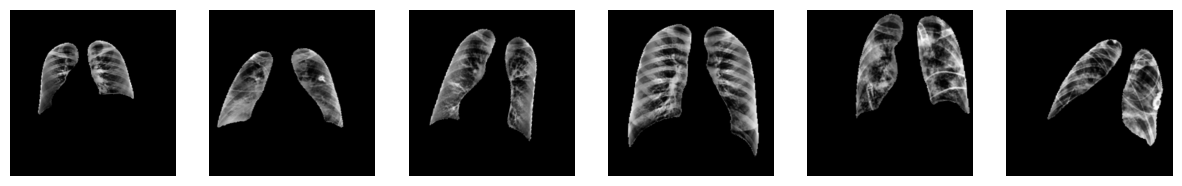

In [25]:


image_size = 299 
BATCH_SIZE = 16 

data_path = workingpath+covid_files
STEPS_PER_EPOCH = nb_files_Covid // BATCH_SIZE





datagen = ImageDataGenerator(rotation_range=10,
                             width_shift_range=0.05,
                             height_shift_range=0.05,zoom_range=0.10,
                             shear_range=5,
                             horizontal_flip=True,
                             fill_mode="nearest",
                             validation_split=0.2
                                   )

train_datagen = datagen.flow_from_directory(
    directory=workingpath+"/COVID-19_Radiography_Filtered_Dataset",
    target_size=(image_size,image_size),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    subset='training'
)

validation_datagen = datagen.flow_from_directory(
                                           directory=workingpath+"/COVID-19_Radiography_Filtered_Dataset",
                                           target_size=(image_size,image_size),
                                           color_mode='grayscale',
                                           batch_size=BATCH_SIZE, 
                                           shuffle=False,
                                           subset = 'validation')


fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(15,15))

for i in range(6):

  # convert to unsigned integers for plotting
  image = next(train_datagen)[0].astype('uint8')


  # plot raw pixel data
  ax[i].imshow(image[1,:,:], cmap='gray')
  ax[i].axis('off')

  


'/home/cyril/liora/projet/COVID-19_Radiography_Dataset'